# 05 — Support Vector Machine (SVM)
Train, evaluate, and save the SVM model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = joblib.load('../../models/splits.pkl')
le = joblib.load('../../models/label_encoder.pkl')
class_names = le.classes_
os.makedirs('../../outputs/plots', exist_ok=True)
print("Data loaded.")

Data loaded.


In [2]:
# Train SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [3]:
# Evaluate
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
train_acc = accuracy_score(y_train, svm.predict(X_train))
gap = train_acc - acc
print(f"SVM Train Accuracy: {train_acc * 100:.2f}%")
print(f"SVM Test Accuracy:  {acc * 100:.2f}%")
print(f"Generalization Gap: {gap * 100:.2f}%")
print("Status:", "Potential overfitting" if gap > 0.03 else "No major overfitting signal")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

SVM Train Accuracy: 95.21%
SVM Test Accuracy:  82.08%
Generalization Gap: 13.12%
Status: Potential overfitting

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.84      0.78      0.81        60
    High Stress       0.89      0.89      0.89       100
Moderate Stress       0.73      0.76      0.74        80

       accuracy                           0.82       240
      macro avg       0.82      0.81      0.81       240
   weighted avg       0.82      0.82      0.82       240



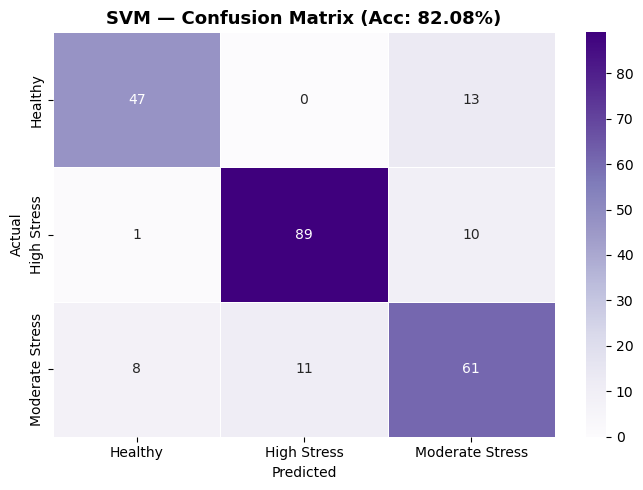

In [4]:
# Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(f'SVM — Confusion Matrix (Acc: {acc*100:.2f}%)', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../../outputs/plots/confusion_matrix_svm.png', dpi=150)
plt.show()

In [5]:
# Cross-Validation
cv_scores = cross_val_score(svm, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

Cross-Validation Scores: [0.7969 0.8385 0.8438 0.8333 0.8438]
Mean CV Accuracy: 83.12% ± 1.76%


In [6]:
joblib.dump(svm, '../../models/svm_model.pkl')
print("Saved: svm_model.pkl")

Saved: svm_model.pkl
